### Import all the necessary libraries

In [119]:
import pandas as pd
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from greedy_auto_time_start_1 import Point, Route
import os
import math
import folium
import osmnx as ox
import networkx as nx
from matplotlib.lines import Line2D

### Import of functions

In [2]:
import greedy_auto_time_start_1 as auto_alg
import greedy_time_simulate_1 as sim_alg
from build_matrices import build_matrices
from k_medoids_2 import find_optimal_n_clusters_kmedoids

In [3]:
OSM_URL = "https://router.project-osrm.org"
OSM_MODE = "driving"
BLOCK_SIZE = 25
CREW_MEMBERS = 3
MAX_WORK_HOURS = 12

### Import the data

In [4]:
depots = pd.read_csv('synthetic_data_kyiv_varash/general.csv')

In [5]:
kyiv = depots[depots['city_name'] == 'Kyiv'].iloc[0]
kyiv_depot = Point("DEPOT", kyiv['depot_lan'], kyiv['depot_lot'], "DEPOT")
varash = depots[depots['city_name'] == 'Varash'].iloc[0]
varash_depot = Point("DEPOT", varash['depot_lan'], varash['depot_lot'], "DEPOT")

In [6]:
depots_simple = pd.read_csv('synthetic_data_ternopil_dubno/general.csv')

In [7]:
ternopil = depots_simple[depots_simple['city_name'] == 'Ternopil'].iloc[0]
ternopil_depot = Point("DEPOT", ternopil['depot_lan'], ternopil['depot_lot'], "DEPOT")
dubno = depots_simple[depots_simple['city_name'] == 'Dubno'].iloc[0]
dubno_depot = Point("DEPOT", dubno['depot_lan'], dubno['depot_lot'], "DEPOT")

In [8]:
kyiv_small = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_15.csv')
kyiv_small_1 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_03.csv')
kyiv_meduim_1 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_22.csv')
kyiv_meduim_2 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_11.csv')
kyiv_meduim_3 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_05.csv')
kyiv_meduim_4 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_12.csv')
kyiv_meduim_5 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_25.csv')
kyiv_gross_1 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_02.csv')
kyiv_gross_2 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_23.csv')
kyiv_gross_3 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_19.csv')
varash_small = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_15.csv')
varash_small_1 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_23.csv')
varash_medium_1 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_10.csv')
varash_medium_2 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_21.csv')
varash_medium_3 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_09.csv')
varash_medium_4 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_24.csv')
varash_medium_5 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_12.csv')
varash_gross_1 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_06.csv')
varash_gross_2 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_02.csv')
varash_gross_3 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_25.csv')
ternopil_small = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_07.csv')
ternopil_small_1 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_25.csv')
ternopil_medium_1 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_22.csv')
ternopil_medium_2 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_14.csv')
ternopil_medium_3 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_23.csv')
ternopil_medium_4 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_24.csv')
ternopil_medium_5 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_13.csv')
ternopil_groos = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_01.csv')
ternopil_groos_2 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_02.csv')
ternopil_groos_3 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_15.csv')
dubno_small = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_01.csv')
dubno_small_1 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_21.csv')
dubno_medium_1 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_22.csv')
dubno_medium_2 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_09.csv')
dubno_medium_3 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_17.csv')
dubno_medium_4 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_16.csv')
dubno_medium_5 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_14.csv')
dubno_gross = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_12.csv')
dubno_gross_2 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_11.csv')
dubno_gross_3 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_07.csv')

In [9]:
def format_points(df):
    '''
    function to convert the data into Point class objects
    '''
    df = df.copy()
    df["point_id"] = df["point_id"].astype(str)
    points = []

    for _, row in df.iterrows():
        tw_start = str(row["tw_start"]).strip() if pd.notna(row["tw_start"]) else None
        tw_end = str(row["tw_end"]).strip() if pd.notna(row["tw_end"]) else None

        point_obj = Point(
            str(row["point_id"]),
            row["lan"],
            row["lot"],
            row["point_type"],
            tw_start,
            tw_end
        )

        points.append(point_obj)

    return points

In [10]:
kyiv_s_p = format_points(kyiv_small)
kyiv_s_1_p = format_points(kyiv_small_1)
kyiv_m_1_p = format_points(kyiv_meduim_1)
kyiv_m_2_p = format_points(kyiv_meduim_2)
kyiv_m_3_p = format_points(kyiv_meduim_3)
kyiv_m_4_p = format_points(kyiv_meduim_4)
kyiv_m_5_p = format_points(kyiv_meduim_5)
kyiv_g_1_p = format_points(kyiv_gross_1)
kyiv_g_2_p = format_points(kyiv_gross_2)
kyiv_g_3_p = format_points(kyiv_gross_3)
varash_s_p = format_points(varash_small)
varash_s_1_p = format_points(varash_small_1)
varash_m_1_p = format_points(varash_medium_1)
varash_m_2_p = format_points(varash_medium_2)
varash_m_3_p = format_points(varash_medium_3)
varash_m_4_p = format_points(varash_medium_4)
varash_m_5_p = format_points(varash_medium_5)
varash_g_1_p = format_points(varash_gross_1)
varash_g_2_p = format_points(varash_gross_2)
varash_g_3_p = format_points(varash_gross_3)
ternopil_s_p = format_points(ternopil_small)
ternopil_s_1_p = format_points(ternopil_small_1)
ternopil_m_1_p = format_points(ternopil_medium_1)
ternopil_m_2_p = format_points(ternopil_medium_2)
ternopil_m_3_p = format_points(ternopil_medium_3)
ternopil_m_4_p = format_points(ternopil_medium_4)
ternopil_m_5_p = format_points(ternopil_medium_5)
ternopil_g_p= format_points(ternopil_groos)
ternopil_g_2_p = format_points(ternopil_groos_2)
ternopil_g_3_p= format_points(ternopil_groos_3)
dubno_s_p = format_points(dubno_small)
dubno_s_1_p = format_points(dubno_small_1)
dubno_m_1_p = format_points(dubno_medium_1)
dubno_m_2_p = format_points(dubno_medium_2)
dubno_m_3_p = format_points(dubno_medium_3)
dubno_m_4_p = format_points(dubno_medium_4)
dubno_m_5_p = format_points(dubno_medium_5)
dubno_g_p = format_points(dubno_gross)
dubno_g_2_p = format_points(dubno_gross_2)
dubno_g_3_p = format_points(dubno_gross_3)

In [11]:
def set_params(crew, crew_members, max_hours_work):
    result = dict()
    result['max_crews'] = crew
    result['max_workers'] =  crew*crew_members
    result['workers_per_crew'] =  crew_members
    result['max_route_duration_min'] = max_hours_work * 60
    return result

In [12]:
params_varash = set_params(varash['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)
params_kyiv = set_params(kyiv['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)
params_ternopil = set_params(ternopil['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)
params_dubno = set_params(dubno['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)

In [13]:
cases = [
        {
            "name": "Kyiv_small",
            "depo": kyiv_depot,
            "stops": kyiv_s_p,
            "params": params_kyiv
        },
        {
            "name": "Kyiv_small_1",
            "depo": kyiv_depot,
            "stops": kyiv_s_1_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_1",
            "depo": kyiv_depot,
            "stops": kyiv_m_1_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_2",
            "depo": kyiv_depot,
            "stops": kyiv_m_2_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_3",
            "depo": kyiv_depot,
            "stops": kyiv_m_3_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_4",
            "depo": kyiv_depot,
            "stops": kyiv_m_4_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_5",
            "depo": kyiv_depot,
            "stops": kyiv_m_5_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_gross_1",
            "depo": kyiv_depot,
            "stops": kyiv_g_1_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_gross_2",
            "depo": kyiv_depot,
            "stops": kyiv_g_2_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_gross_3",
            "depo": kyiv_depot,
            "stops": kyiv_g_3_p,
            "params": params_kyiv
        },
        {
            "name": "Varash_small",
            "depo": varash_depot,
            "stops": varash_s_p,
            "params": params_varash
        },
        {
            "name": "Varash_small_1",
            "depo": varash_depot,
            "stops": varash_s_1_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_1",
            "depo": varash_depot,
            "stops": varash_m_1_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_2",
            "depo": varash_depot,
            "stops": varash_m_2_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_3",
            "depo": varash_depot,
            "stops": varash_m_3_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_4",
            "depo": varash_depot,
            "stops": varash_m_4_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_5",
            "depo": varash_depot,
            "stops": varash_m_5_p,
            "params": params_varash
        },
        {
            "name": "Varash_gross_1",
            "depo": varash_depot,
            "stops": varash_g_1_p,
            "params": params_varash
        },
        {
            "name": "Varash_gross_2",
            "depo": varash_depot,
            "stops": varash_g_2_p,
            "params": params_varash
        },
        {
            "name": "Varash_gross_3",
            "depo": varash_depot,
            "stops": varash_g_3_p,
            "params": params_varash
        }
]

In [14]:
cases_simple = [
        {
            "name": "ternopil_small",
            "depo": ternopil_depot,
            "stops": ternopil_s_p,
            "params": params_ternopil
        },
        {
            "name": "ternopil_small_1",
            "depo": ternopil_depot,
            "stops": ternopil_s_1_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_1",
            "depo": ternopil_depot,
            "stops": ternopil_m_1_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_2",
            "depo": ternopil_depot,
            "stops": ternopil_m_2_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_3",
            "depo": ternopil_depot,
            "stops": ternopil_m_3_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_4",
            "depo": ternopil_depot,
            "stops": ternopil_m_4_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_5",
            "depo": ternopil_depot,
            "stops": ternopil_m_5_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_gross_1",
            "depo": ternopil_depot,
            "stops": ternopil_g_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_gross_2",
            "depo": ternopil_depot,
            "stops": ternopil_g_2_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_gross_3",
            "depo": ternopil_depot,
            "stops": ternopil_g_3_p,
            "params": params_ternopil
        },
        {
            "name": "dubno_small",
            "depo": dubno_depot,
            "stops": dubno_s_p,
            "params": params_dubno
        },
        {
            "name": "dubno_small_1",
            "depo": dubno_depot,
            "stops": dubno_s_1_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_1",
            "depo": dubno_depot,
            "stops": dubno_m_1_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_2",
            "depo": dubno_depot,
            "stops": dubno_m_2_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_3",
            "depo": dubno_depot,
            "stops": dubno_m_3_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_4",
            "depo": dubno_depot,
            "stops": dubno_m_4_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_5",
            "depo": dubno_depot,
            "stops": dubno_m_5_p,
            "params": params_dubno
        },
        {
            "name": "dubno_gross_1",
            "depo": dubno_depot,
            "stops": dubno_g_p,
            "params": params_dubno
        },
        {
            "name": "dubno_gross_2",
            "depo": dubno_depot,
            "stops": dubno_g_2_p,
            "params": params_dubno
        },
        {
            "name": "dubno_gross_3",
            "depo": dubno_depot,
            "stops": dubno_g_3_p,
            "params": params_dubno
        }
]

### Run the clasterization

In [15]:
fixed_seed = 42
best_iter_num = 10

In [16]:
def run_clusterization(cases, function, fixed_seed, iter_num, extra_kwargs=None):
    all_results = []
    
    for case in cases:
        name = case["name"]
        current_cache = f"cache_routes/cache_{name}.json"

        coords = [(case["depo"].lat, case["depo"].lon)] + [
            (s.lat, s.lon) for s in case["stops"]
        ]

        dist_km, time_min = build_matrices(
            coords=coords,
            cache_path=current_cache,
            name=name,
            block_size=25,
            osm_url=OSM_URL,
            osm_mode=OSM_MODE
        )

        build_routes_kwargs = {
            "max_crews": case["params"]["max_crews"],
            "max_workers": case["params"]["max_workers"],
            "workers_per_crew": case["params"]["workers_per_crew"],
            "max_route_duration_min": case["params"]["max_route_duration_min"],
        }

        if extra_kwargs is not None:
            build_routes_kwargs.update(extra_kwargs)

        result = find_optimal_n_clusters_kmedoids(
            day_stops=case["stops"],
            depo=case["depo"],
            dist_km=dist_km,
            time_min=time_min,
            max_crews=case["params"]["max_crews"],
            build_routes_ag=function,
            build_routes_kwargs=build_routes_kwargs,
            random_state=fixed_seed,
            max_iter=iter_num
        )

        case_result = {
            "case_name": name,
            "day_stops": case["stops"],
            "depo": case["depo"],
            "params": case["params"],
            "dist_km": dist_km,
            "time_min": time_min,
            "cluster_result": result,
            "routes": result["routes"],
            "summary": result["summary"],
            "labels": result["labels"],
            "medoid_indices": result["medoid_indices"],
            "cluster_details": result["cluster_details"],
        }

        all_results.append(case_result)

    return all_results

In [17]:
clust_data_original_math = run_clusterization(cases, auto_alg.build_routes, fixed_seed, best_iter_num)
clust_data_original_sim = run_clusterization(cases, sim_alg.build_routes, fixed_seed, best_iter_num, 
        extra_kwargs={
        "start_from": "08:00",
        "start_to": "10:00",
        "step_min": 10,
        "target_duration": 480
    })

In [18]:
clust_data_simple_math = run_clusterization(cases_simple, auto_alg.build_routes, fixed_seed, best_iter_num)
clust_data_simple_sim = run_clusterization(cases_simple, sim_alg.build_routes, fixed_seed, best_iter_num, 
        extra_kwargs={
        "start_from": "08:00",
        "start_to": "10:00",
        "step_min": 10,
        "target_duration": 480
    })

### Greedy

In [41]:
def run_greedy_for_cases(cases, greedy_build_routes_func, start_time_approach, extra_kwargs=None):
    results = []

    for case in cases:
        name = case["name"]
        current_cache = f"cache_routes/cache_{name}.json"

        coords = [(case["depo"].lat, case["depo"].lon)] + [
            (s.lat, s.lon) for s in case["stops"]
        ]

        dist_km, time_min = build_matrices(
            coords=coords,
            cache_path=current_cache,
            name=name,
            block_size=25,
            osm_url=OSM_URL,
            osm_mode=OSM_MODE
        )

        build_routes_kwargs = {
            "day_stops": case["stops"],
            "depo": case["depo"],
            "dist_km": dist_km,
            "times": time_min,
            "max_crews": case["params"]["max_crews"],
            "max_workers": case["params"]["max_workers"],
            "workers_per_crew": case["params"]["workers_per_crew"],
            "max_route_duration_min": case["params"]["max_route_duration_min"],
        }

        if extra_kwargs is not None:
            build_routes_kwargs.update(extra_kwargs)

        try:
            routes = greedy_build_routes_func(**build_routes_kwargs)

            total_duration = sum(r.end_time - r.start_time for r in routes)
            total_distance = sum(r.distance_km for r in routes)
            routes_count = len(routes)
            served_points = sum(r.served_count for r in routes)

            results.append({
                "case_name": name,
                "start_time_approach": start_time_approach,
                "algorithm": "Greedy",
                "total_duration": total_duration,
                "total_distance": total_distance,
                "routes_count": routes_count,
                "served_points": served_points,
                "status": "ok"
            })

        except Exception as e:
            results.append({
                "case_name": name,
                "start_time_approach": start_time_approach,
                "algorithm": "Greedy",
                "total_duration": None,
                "total_distance": None,
                "routes_count": None,
                "served_points": None,
                "status": "failed",
                "error": str(e)
            })

    return pd.DataFrame(results)

In [42]:
greedy_original_math = run_greedy_for_cases(
    cases=cases,
    greedy_build_routes_func=auto_alg.build_routes,
    start_time_approach="Math"
)

In [44]:
greedy_original_sim = run_greedy_for_cases(
    cases=cases,
    greedy_build_routes_func=sim_alg.build_routes,
    start_time_approach="Simulation",
    extra_kwargs={
        "start_from": "08:00",
        "start_to": "10:00",
        "step_min": 10,
        "target_duration": 480
    }
)

In [45]:
greedy_simple_math = run_greedy_for_cases(
    cases=cases_simple,
    greedy_build_routes_func=auto_alg.build_routes,
    start_time_approach="Math"
)

In [46]:
greedy_simple_sim = run_greedy_for_cases(
    cases=cases_simple,
    greedy_build_routes_func=sim_alg.build_routes,
    start_time_approach="Simulation",
    extra_kwargs={
        "start_from": "08:00",
        "start_to": "10:00",
        "step_min": 10,
        "target_duration": 480
    }
)

In [47]:
greedy_all = pd.concat([greedy_original_math, greedy_original_sim, greedy_simple_math, greedy_simple_sim], ignore_index=True)

In [48]:
greedy_all

,case_name,start_time_approach,algorithm,total_duration,total_distance,routes_count,served_points,status
0,Kyiv_small,Math,Greedy,12060.058333,2761.1567,17,405,ok
1,Kyiv_small_1,Math,Greedy,10589.066667,2443.3840,15,411,ok
2,Kyiv_medium_1,Math,Greedy,11949.648333,3058.8621,17,498,ok
3,Kyiv_medium_2,Math,Greedy,13367.133333,2969.6469,19,480,ok
4,Kyiv_medium_3,Math,Greedy,12813.593333,2999.9583,18,449,ok
...,...,...,...,...,...,...,...,...
75,dubno_medium_4,Simulation,Greedy,624.343333,99.0422,2,33,ok
76,dubno_medium_5,Simulation,Greedy,403.488333,107.9860,1,39,ok
77,dubno_gross_1,Simulation,Greedy,967.190000,143.1792,2,60,ok
78,dubno_gross_2,Simulation,Greedy,866.283333,141.8551,2,47,ok


### VNS

In [30]:
from vns_3 import GlobalVNS, InfeasibleError

In [31]:
def run_vns_parameter_testing(
    clustered_cases,
    route_cls,
    max_iterations_grid,
    local_search_max_iter_grid,
    seeds,
    k_max=5):

    results = []
    for case in clustered_cases:
        case_name = case["case_name"]

        for seed, max_iterations, local_search_max_iter in product(
            seeds, max_iterations_grid, local_search_max_iter_grid
        ):
            vns = GlobalVNS(
                day_stops=case["day_stops"],
                depo=case["depo"],
                dist_km=case["dist_km"],
                time_min=case["time_min"],
                max_route_duration_min=case["params"]["max_route_duration_min"],
                random_state=seed
            )

            k_history = []
            original_shake = vns.shake

            def tracked_shake(solution, k):
                k_history.append(k)
                return original_shake(solution, k)

            vns.shake = tracked_shake

            try:
                best_routes, best_value = vns.main_vns(
                    initial_routes=case["routes"],
                    route_cls=route_cls,
                    max_iterations=max_iterations,
                    k_max=k_max,
                    local_search_max_iter=local_search_max_iter
                )

                total_duration, total_distance = best_value

                results.append({
                    "case_name": case_name,
                    "seed": seed,
                    "max_iterations": max_iterations,
                    "local_search_max_iter": local_search_max_iter,
                    "k_max": k_max,
                    "total_duration": total_duration,
                    "total_distance": total_distance,
                    "max_k_reached": max(k_history) if k_history else None,
                    "mean_k_reached": sum(k_history) / len(k_history) if k_history else None,
                    "n_shake_calls": len(k_history),
                    "status": "ok",
                    "best_routes": best_routes
                })

            except InfeasibleError as e:
                results.append({
                    "case_name": case_name,
                    "seed": seed,
                    "max_iterations": max_iterations,
                    "local_search_max_iter": local_search_max_iter,
                    "k_max": k_max,
                    "total_duration": float("inf"),
                    "total_distance": float("inf"),
                    "max_k_reached": max(k_history) if k_history else None,
                    "mean_k_reached": sum(k_history) / len(k_history) if k_history else None,
                    "n_shake_calls": len(k_history),
                    "status": f"infeasible: {str(e)}",
                    "best_routes": None
                })

            finally:
                vns.shake = original_shake

    return pd.DataFrame(results)

In [32]:
the_best_local_search_max_iter = [20]
the_best_max_iterations = [5000]
seeds = [42]

In [33]:
vns_test_math_original = run_vns_parameter_testing(
    clustered_cases=clust_data_original_math,
    route_cls=Route,
    max_iterations_grid=the_best_max_iterations,
    local_search_max_iter_grid=the_best_local_search_max_iter,
    seeds=seeds,
    k_max=5
)

In [34]:
vns_test_sim_original = run_vns_parameter_testing(
    clustered_cases=clust_data_original_sim,
    route_cls=Route,
    max_iterations_grid=the_best_max_iterations,
    local_search_max_iter_grid=the_best_local_search_max_iter,
    seeds=seeds,
    k_max=5
)

In [35]:
vns_test_math_simple = run_vns_parameter_testing(
    clustered_cases=clust_data_simple_math,
    route_cls=Route,
    max_iterations_grid=the_best_max_iterations,
    local_search_max_iter_grid=the_best_local_search_max_iter,
    seeds=seeds,
    k_max=5
)

In [36]:
vns_test_sim_simple = run_vns_parameter_testing(
    clustered_cases=clust_data_simple_sim,
    route_cls=Route,
    max_iterations_grid=the_best_max_iterations,
    local_search_max_iter_grid=the_best_local_search_max_iter,
    seeds=seeds,
    k_max=5
)

In [57]:
vns_all = pd.concat([
    vns_test_math_original.assign(start_time_approach="Math"),
    vns_test_sim_original.assign(start_time_approach="Simulation"),
    vns_test_math_simple.assign(start_time_approach="Math"),
    vns_test_sim_simple.assign(start_time_approach="Simulation"),
], ignore_index=True)
vns_all["algorithm"] = "VNS"

In [58]:
vns_all

,case_name,seed,max_iterations,local_search_max_iter,k_max,total_duration,total_distance,max_k_reached,mean_k_reached,n_shake_calls,status,best_routes,start_time_approach,algorithm
0,Kyiv_small,42,5000,20,5,8985.515000,2597.9770,5,2.938004,26776,ok,"[Route(crew_id=2, stop_sequence=['DEPOT', 'KYI...",Math,VNS
1,Kyiv_small_1,42,5000,20,5,8692.168333,2993.3254,5,2.922210,27497,ok,"[Route(crew_id=2, stop_sequence=['DEPOT', 'KYI...",Math,VNS
2,Kyiv_medium_1,42,5000,20,5,7974.470000,3034.4606,5,2.935122,26804,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'KYI...",Math,VNS
3,Kyiv_medium_2,42,5000,20,5,9903.215000,3910.7937,5,2.886643,28750,ok,"[Route(crew_id=3, stop_sequence=['DEPOT', 'KYI...",Math,VNS
4,Kyiv_medium_3,42,5000,20,5,9587.853333,2240.8814,5,2.959968,25954,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'KYI...",Math,VNS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,dubno_medium_4,42,5000,20,5,484.768333,61.5146,5,2.996418,25127,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Simulation,VNS
76,dubno_medium_5,42,5000,20,5,403.488333,77.8464,5,2.996862,25175,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Simulation,VNS
77,dubno_gross_1,42,5000,20,5,630.716667,122.1404,5,2.987401,25319,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Simulation,VNS
78,dubno_gross_2,42,5000,20,5,531.915000,95.3985,5,2.995491,25284,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Simulation,VNS


### ALNS

In [19]:
from alns_3 import GlobalALNS, InfeasibleError

In [20]:
def run_alns_parameter_testing(
    clustered_cases,
    route_cls,
    max_iterations,
    q_min_q_max,
    seeds,
    initial_temperature=50.0,
    cooling_rate=0.995,
    reaction_factor=0.2,
    segment_length=25,
    score_global_best=5.0,
    score_improved_current=3.0,
    score_accepted_worse=1.0):
    results = []

    for case in clustered_cases:
        case_name = case["case_name"]

        for seed, max_iter, q_pair in product(seeds, max_iterations, q_min_q_max):
            q_min, q_max = q_pair

            alns = GlobalALNS(
                day_stops=case["day_stops"],
                depo=case["depo"],
                dist_km=case["dist_km"],
                time_min=case["time_min"],
                max_route_duration_min=case["params"]["max_route_duration_min"],
                random_state=seed
            )

            destroy_history = []
            repair_history = []

            original_apply_destroy = alns.apply_destroy
            original_apply_repair = alns.apply_repair

            def tracked_apply_destroy(operator_name, solution, q):
                destroy_history.append(operator_name)
                return original_apply_destroy(operator_name, solution, q)

            def tracked_apply_repair(operator_name, partial_solution, removed_points):
                repair_history.append(operator_name)
                return original_apply_repair(operator_name, partial_solution, removed_points)

            alns.apply_destroy = tracked_apply_destroy
            alns.apply_repair = tracked_apply_repair

            try:
                best_routes, best_value = alns.main_alns(
                    initial_routes=case["routes"],
                    route_cls=route_cls,
                    max_iterations=max_iter,
                    q_min=q_min,
                    q_max=q_max,
                    initial_temperature=initial_temperature,
                    cooling_rate=cooling_rate,
                    reaction_factor=reaction_factor,
                    segment_length=segment_length,
                    score_global_best=score_global_best,
                    score_improved_current=score_improved_current,
                    score_accepted_worse=score_accepted_worse
                )

                total_duration, total_distance = best_value

                results.append({
                    "case_name": case_name,
                    "seed": seed,
                    "max_iterations": max_iter,
                    "q_min": q_min,
                    "q_max": q_max,
                    "initial_temperature": initial_temperature,
                    "cooling_rate": cooling_rate,
                    "segment_length": segment_length,
                    "total_duration": total_duration,
                    "total_distance": total_distance,
                    "n_destroy_calls": len(destroy_history),
                    "n_repair_calls": len(repair_history),
                    "random_removal_count": destroy_history.count("random_removal"),
                    "worst_removal_count": destroy_history.count("worst_removal"),
                    "greedy_insertion_count": repair_history.count("greedy_insertion"),
                    "regret_insertion_count": repair_history.count("regret_insertion"),
                    "status": "ok",
                    "best_routes": best_routes
                })

            except InfeasibleError as e:
                results.append({
                    "case_name": case_name,
                    "seed": seed,
                    "max_iterations": max_iter,
                    "q_min": q_min,
                    "q_max": q_max,
                    "initial_temperature": initial_temperature,
                    "cooling_rate": cooling_rate,
                    "segment_length": segment_length,
                    "total_duration": float("inf"),
                    "total_distance": float("inf"),
                    "n_destroy_calls": len(destroy_history),
                    "n_repair_calls": len(repair_history),
                    "random_removal_count": destroy_history.count("random_removal"),
                    "worst_removal_count": destroy_history.count("worst_removal"),
                    "greedy_insertion_count": repair_history.count("greedy_insertion"),
                    "regret_insertion_count": repair_history.count("regret_insertion"),
                    "status": f"infeasible: {str(e)}",
                    "best_routes": None
                })

            finally:
                alns.apply_destroy = original_apply_destroy
                alns.apply_repair = original_apply_repair

    return pd.DataFrame(results)

In [23]:
max_iterations = [1000]
q_min_q_max = [(2, 5)]
seeds = [42]

In [24]:
alns_original_math = run_alns_parameter_testing(
    clustered_cases=clust_data_original_math,
    route_cls=Route,
    max_iterations=max_iterations,
    q_min_q_max=q_min_q_max,
    seeds=seeds
)

In [25]:
alns_original_sim = run_alns_parameter_testing(
    clustered_cases=clust_data_original_sim,
    route_cls=Route,
    max_iterations=max_iterations,
    q_min_q_max=q_min_q_max,
    seeds=seeds
)

In [28]:
alns_simple_math = run_alns_parameter_testing(
    clustered_cases=clust_data_simple_math,
    route_cls=Route,
    max_iterations=max_iterations,
    q_min_q_max=q_min_q_max,
    seeds=seeds
)

In [29]:
alns_simple_sim = run_alns_parameter_testing(
    clustered_cases=clust_data_simple_sim,
    route_cls=Route,
    max_iterations=max_iterations,
    q_min_q_max=q_min_q_max,
    seeds=seeds
)

In [59]:
alns_all = pd.concat([
    alns_original_math.assign(start_time_approach="Math"),
    alns_original_sim.assign(start_time_approach="Simulation"),
    alns_simple_math.assign(start_time_approach="Math"),
    alns_simple_sim.assign(start_time_approach="Simulation"),
], ignore_index=True)
alns_all["algorithm"] = "ALNS"

In [54]:
alns_all

,case_name,seed,max_iterations,q_min,q_max,initial_temperature,cooling_rate,segment_length,total_duration,total_distance,n_destroy_calls,n_repair_calls,random_removal_count,worst_removal_count,greedy_insertion_count,regret_insertion_count,status,best_routes,Method,algorithm
0,Kyiv_small,42,1000,2,5,50.0,0.995,25,8959.191667,1935.0848,1000,1000,707,293,499,501,ok,"[Route(crew_id=2, stop_sequence=['DEPOT', 'KYI...",Math,ALNS
1,Kyiv_small_1,42,1000,2,5,50.0,0.995,25,7606.421667,1903.9342,1000,1000,667,333,489,511,ok,"[Route(crew_id=3, stop_sequence=['DEPOT', 'KYI...",Math,ALNS
2,Kyiv_medium_1,42,1000,2,5,50.0,0.995,25,7402.750000,2035.8469,1000,1000,724,276,477,523,ok,"[Route(crew_id=3, stop_sequence=['DEPOT', 'KYI...",Math,ALNS
3,Kyiv_medium_2,42,1000,2,5,50.0,0.995,25,9089.878333,1997.7049,1000,1000,727,273,505,495,ok,"[Route(crew_id=3, stop_sequence=['DEPOT', 'KYI...",Math,ALNS
4,Kyiv_medium_3,42,1000,2,5,50.0,0.995,25,8220.723333,1863.2623,1000,1000,703,297,502,498,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'KYI...",Math,ALNS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,dubno_medium_4,42,1000,2,5,50.0,0.995,25,484.768333,64.0353,1000,1000,528,472,450,550,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Simulation,ALNS
76,dubno_medium_5,42,1000,2,5,50.0,0.995,25,403.488333,77.9819,1000,1000,581,419,424,576,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Simulation,ALNS
77,dubno_gross_1,42,1000,2,5,50.0,0.995,25,619.346667,113.3602,1000,1000,544,456,409,591,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Simulation,ALNS
78,dubno_gross_2,42,1000,2,5,50.0,0.995,25,532.081667,94.6440,1000,1000,540,460,446,554,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Simulation,ALNS


### Comparison

In [55]:
all_results = pd.concat([
    greedy_all,
    vns_all,
    alns_all
], ignore_index=True)

all_results.head()

,case_name,start_time_approach,algorithm,total_duration,total_distance,routes_count,served_points,status,seed,max_iterations,...,q_max,initial_temperature,cooling_rate,segment_length,n_destroy_calls,n_repair_calls,random_removal_count,worst_removal_count,greedy_insertion_count,regret_insertion_count
0,Kyiv_small,Math,Greedy,12060.058333,2761.1567,17.0,405.0,ok,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Kyiv_small_1,Math,Greedy,10589.066667,2443.3840,15.0,411.0,ok,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Kyiv_medium_1,Math,Greedy,11949.648333,3058.8621,17.0,498.0,ok,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Kyiv_medium_2,Math,Greedy,13367.133333,2969.6469,19.0,480.0,ok,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kyiv_medium_3,Math,Greedy,12813.593333,2999.9583,18.0,449.0,ok,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
needed_cols = [
    "case_name",
    "start_time_approach",
    "algorithm",
    "total_duration",
    "total_distance",
    "routes_count",
    "served_points",
    "status"
]

vns_all["routes_count"] = vns_all["best_routes"].apply(len)
vns_all["served_points"] = vns_all["best_routes"].apply(
    lambda routes: sum(r.served_count for r in routes)
)

alns_all["routes_count"] = alns_all["best_routes"].apply(len)
alns_all["served_points"] = alns_all["best_routes"].apply(
    lambda routes: sum(r.served_count for r in routes)
)

all_results = pd.concat([
    greedy_all[needed_cols],
    vns_all[needed_cols],
    alns_all[needed_cols]
], ignore_index=True)

In [66]:
def extract_dataset(case_name):
    if "Kyiv" in case_name:
        return "Kyiv"
    elif "Varash" in case_name:
        return "Varash"
    elif "ternopil" in case_name:
        return "Ternopil"
    elif "dubno" in case_name:
        return "Dubno"
    else:
        return "Unknown"

all_results["dataset"] = all_results["case_name"].apply(extract_dataset)

In [71]:
summary_table = (
    all_results[all_results["status"] == "ok"]
    .groupby(["dataset", "start_time_approach", "algorithm"])
    .agg(
        avg_total_duration=("total_duration", "mean"),
        avg_total_distance=("total_distance", "mean"),
        avg_routes_count=("routes_count", "mean"),
        avg_served_points=("served_points", "mean")
    )
    .reset_index()
)

summary_table

,dataset,start_time_approach,algorithm,avg_total_duration,avg_total_distance,avg_routes_count,avg_served_points
0,Dubno,Math,ALNS,495.469333,87.65668,1.1,44.9
1,Dubno,Math,Greedy,606.732667,116.33026,1.6,44.9
2,Dubno,Math,VNS,495.059167,85.37254,1.2,44.9
3,Dubno,Simulation,ALNS,506.084500,87.29834,1.1,44.9
4,Dubno,Simulation,Greedy,677.566333,117.74109,1.7,44.9
5,Dubno,Simulation,VNS,506.819167,86.62817,1.2,44.9
6,Kyiv,Math,ALNS,9076.076833,2182.28322,14.0,489.8
7,Kyiv,Math,Greedy,12772.252000,2949.43630,18.0,489.8
8,Kyiv,Math,VNS,9884.256667,3383.44701,14.7,489.8
9,Kyiv,Simulation,ALNS,7199.299000,2077.44312,11.6,489.8


In [72]:
summary_table["duration_rank"] = (
    summary_table
    .groupby(["dataset", "start_time_approach"])["avg_total_duration"]
    .rank(method="dense")
)

summary_table.sort_values(
    ["dataset", "start_time_approach", "duration_rank"]
)

,dataset,start_time_approach,algorithm,avg_total_duration,avg_total_distance,avg_routes_count,avg_served_points,duration_rank
2,Dubno,Math,VNS,495.059167,85.37254,1.2,44.9,1.0
0,Dubno,Math,ALNS,495.469333,87.65668,1.1,44.9,2.0
1,Dubno,Math,Greedy,606.732667,116.33026,1.6,44.9,3.0
3,Dubno,Simulation,ALNS,506.084500,87.29834,1.1,44.9,1.0
5,Dubno,Simulation,VNS,506.819167,86.62817,1.2,44.9,2.0
4,Dubno,Simulation,Greedy,677.566333,117.74109,1.7,44.9,3.0
6,Kyiv,Math,ALNS,9076.076833,2182.28322,14.0,489.8,1.0
8,Kyiv,Math,VNS,9884.256667,3383.44701,14.7,489.8,2.0
7,Kyiv,Math,Greedy,12772.252000,2949.43630,18.0,489.8,3.0
9,Kyiv,Simulation,ALNS,7199.299000,2077.44312,11.6,489.8,1.0


In [75]:
summary_table["duration_rank"] = (
    summary_table
    .groupby(["dataset", "start_time_approach"])["avg_total_duration"]
    .rank(method="dense")
)

winners = summary_table[summary_table["duration_rank"] == 1].copy()
overall_wins = (
    winners
    .groupby("algorithm")
    .size()
    .reset_index(name="total_wins")
    .sort_values("total_wins", ascending=False)
)

overall_wins

,algorithm,total_wins
0,ALNS,4
1,VNS,4


In [78]:
baseline = summary_table[
    summary_table["algorithm"] == "Greedy"
][[
    "dataset",
    "start_time_approach",
    "avg_total_duration",
    "avg_total_distance",
    "avg_routes_count"
]].rename(columns={
    "avg_total_duration": "greedy_duration",
    "avg_total_distance": "greedy_distance",
    "avg_routes_count": "greedy_routes"
})

comparison = summary_table.merge(
    baseline,
    on=["dataset", "start_time_approach"],
    how="left"
)

comparison["duration_reduction_vs_greedy_%"] = (
    (comparison["greedy_duration"] - comparison["avg_total_duration"])
    / comparison["greedy_duration"] * 100
)

comparison["distance_change_vs_greedy_%"] = (
    (comparison["avg_total_distance"] - comparison["greedy_distance"])
    / comparison["greedy_distance"] * 100
)

comparison["routes_change_vs_greedy"] = (
    comparison["avg_routes_count"] - comparison["greedy_routes"]
)

comparison["best_in_group"] = comparison["duration_rank"].eq(1)

comparison_clean = comparison[[
    "dataset",
    "start_time_approach",
    "algorithm",
    "best_in_group",
    "avg_total_duration",
    "duration_reduction_vs_greedy_%",
    "avg_total_distance",
    "distance_change_vs_greedy_%",
    "avg_routes_count",
    "routes_change_vs_greedy"
]].sort_values(
    ["dataset", "start_time_approach", "best_in_group", "avg_total_duration"],
    ascending=[True, True, False, True]
)

comparison_clean

,dataset,start_time_approach,algorithm,best_in_group,avg_total_duration,duration_reduction_vs_greedy_%,avg_total_distance,distance_change_vs_greedy_%,avg_routes_count,routes_change_vs_greedy
2,Dubno,Math,VNS,True,495.059167,18.405717,85.37254,-26.611924,1.2,-0.4
0,Dubno,Math,ALNS,False,495.469333,18.338115,87.65668,-24.648428,1.1,-0.5
1,Dubno,Math,Greedy,False,606.732667,0.000000,116.33026,0.000000,1.6,0.0
3,Dubno,Simulation,ALNS,True,506.084500,25.308494,87.29834,-25.855672,1.1,-0.6
5,Dubno,Simulation,VNS,False,506.819167,25.200067,86.62817,-26.424862,1.2,-0.5
4,Dubno,Simulation,Greedy,False,677.566333,0.000000,117.74109,0.000000,1.7,0.0
6,Kyiv,Math,ALNS,True,9076.076833,28.939103,2182.28322,-26.010159,14.0,-4.0
8,Kyiv,Math,VNS,False,9884.256667,22.611481,3383.44701,14.715039,14.7,-3.3
7,Kyiv,Math,Greedy,False,12772.252000,0.000000,2949.43630,0.000000,18.0,0.0
9,Kyiv,Simulation,ALNS,True,7199.299000,37.082834,2077.44312,-24.503034,11.6,-4.8


In [79]:
best_overall = (
    comparison_clean[comparison_clean["best_in_group"] == True]
    .sort_values(["dataset", "avg_total_duration"])
    .groupby("dataset")
    .first()
    .reset_index()
)

best_overall = best_overall[[
    "dataset",
    "start_time_approach",
    "algorithm",
    "avg_total_duration",
    "avg_total_distance",
    "avg_routes_count"
]]

best_overall

,dataset,start_time_approach,algorithm,avg_total_duration,avg_total_distance,avg_routes_count
0,Dubno,Math,VNS,495.059167,85.37254,1.2
1,Kyiv,Simulation,ALNS,7199.299000,2077.44312,11.6
2,Ternopil,Simulation,VNS,2967.609667,515.77545,4.9
3,Varash,Math,ALNS,855.628667,336.60422,1.9


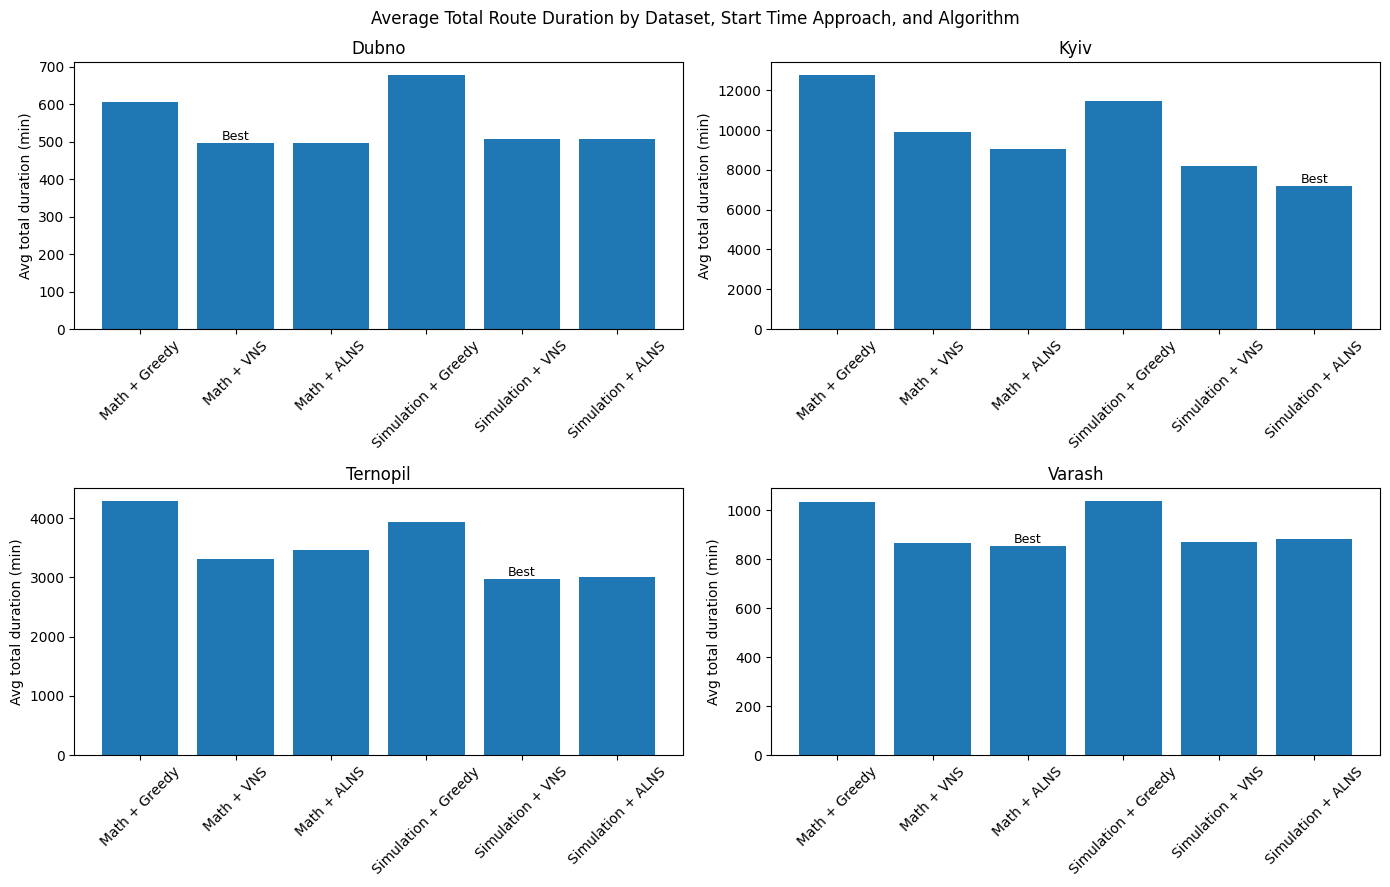

In [83]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = summary_table.copy()

plot_data["config"] = (
    plot_data["start_time_approach"] + " + " + plot_data["algorithm"]
)

datasets = plot_data["dataset"].unique()
configs = [
    "Math + Greedy", "Math + VNS", "Math + ALNS",
    "Simulation + Greedy", "Simulation + VNS", "Simulation + ALNS"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, dataset in zip(axes, datasets):
    subset = plot_data[plot_data["dataset"] == dataset].copy()

    values = []
    for config in configs:
        value = subset.loc[subset["config"] == config, "avg_total_duration"]
        values.append(value.iloc[0] if len(value) > 0 else np.nan)

    ax.bar(configs, values)
    ax.set_title(dataset)
    ax.set_ylabel("Avg total duration (min)")
    ax.tick_params(axis="x", rotation=45)

    min_value = np.nanmin(values)
    best_idx = np.nanargmin(values)
    ax.text(
        best_idx,
        min_value,
        "Best",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.suptitle("Average Total Route Duration by Dataset, Start Time Approach, and Algorithm")
plt.tight_layout()
plt.show()

In [84]:
final_comparison_table = (
    comparison_clean[comparison_clean["best_in_group"] == True]
    .sort_values(["dataset", "avg_total_duration"])
    .groupby("dataset")
    .first()
    .reset_index()
)

final_comparison_table = final_comparison_table[[
    "dataset",
    "start_time_approach",
    "algorithm",
    "avg_total_duration",
    "duration_reduction_vs_greedy_%",
    "avg_total_distance",
    "avg_routes_count"
]]

final_comparison_table

,dataset,start_time_approach,algorithm,avg_total_duration,duration_reduction_vs_greedy_%,avg_total_distance,avg_routes_count
0,Dubno,Math,VNS,495.059167,18.405717,85.37254,1.2
1,Kyiv,Simulation,ALNS,7199.299000,37.082834,2077.44312,11.6
2,Ternopil,Simulation,VNS,2967.609667,24.554576,515.77545,4.9
3,Varash,Math,ALNS,855.628667,17.156205,336.60422,1.9


### Visualization

In [ ]:
def _point_lat_lon(point):
    """Return (lat, lon) for Point-like objects used in the notebook."""
    lat = getattr(point, "lat", None)
    lon = getattr(point, "lon", None)

    if lat is None:
        lat = getattr(point, "lan", None)
    if lon is None:
        lon = getattr(point, "lot", None)

    if lat is None or lon is None:
        raise AttributeError(
            "Point object must have either (lat, lon) or (lan, lot) attributes."
        )

    return float(lat), float(lon)


def _is_point_like(obj):
    return (
        (hasattr(obj, "lat") or hasattr(obj, "lan"))
        and (hasattr(obj, "lon") or hasattr(obj, "lot"))
    )


def _clean_points(points):
    cleaned = []
    for p in points:
        if p is None:
            continue
        point_id = str(getattr(p, "point_id", getattr(p, "id", ""))).upper()
        point_type = str(getattr(p, "point_type", "")).upper()
        if point_id == "DEPOT" or point_type == "DEPOT":
            continue
        cleaned.append(p)
    return cleaned


def _points_from_indices(indices, point_pool):
    """
    Convert numeric route representation to Point objects.
    The notebook matrices are built as [depot] + stops, therefore index 0 is skipped,
    and index i corresponds to point_pool[i-1].
    """
    if point_pool is None:
        return None

    converted = []
    for idx in indices:
        if isinstance(idx, float) and idx.is_integer():
            idx = int(idx)
        if not isinstance(idx, (int, np.integer)):
            return None
        if idx == 0:
            continue
        if 1 <= idx <= len(point_pool):
            converted.append(point_pool[idx - 1])
        elif 0 <= idx < len(point_pool):
            converted.append(point_pool[idx])
        else:
            return None
    return converted


def _find_case_stops(case_name):
    """Find original stops for a case from variables already created in the notebook."""
    candidate_case_lists = [
        globals().get("cases"),
        globals().get("clust_data_original_math"),
        globals().get("clust_data_original_sim"),
        globals().get("clust_data_simple_math"),
        globals().get("clust_data_simple_sim"),
    ]

    for case_list in candidate_case_lists:
        if not isinstance(case_list, list):
            continue
        for case in case_list:
            if not isinstance(case, dict):
                continue
            name = case.get("name", case.get("case_name"))
            if name == case_name:
                return case.get("stops", case.get("day_stops"))
    return None

def _extract_route_points(route, point_pool=None, debug=False):
    """
    Extract route points from Route object.

    Your Route has:
        route.stop_sequence = ['DEPOT', 'KYI...', ...]

    Therefore we map stop IDs from stop_sequence back to Stop objects
    using point_pool.
    """

    if debug:
        print(route)
        print(route.__dict__ if hasattr(route, "__dict__") else dir(route))

    if not hasattr(route, "stop_sequence"):
        raise AttributeError("Route object does not have stop_sequence.")

    stop_sequence = route.stop_sequence

    if point_pool is None:
        raise ValueError(
            "point_pool is None. You need to pass the list of stops for this case."
        )

    def get_stop_id(stop):
        return str(
            getattr(stop, "point_id",
            getattr(stop, "stop_id",
            getattr(stop, "id",
            getattr(stop, "name", ""))))
        )

    stop_dict = {get_stop_id(stop): stop for stop in point_pool}

    route_points = []

    for stop_id in stop_sequence:
        stop_id = str(stop_id)

        if stop_id.upper() == "DEPOT":
            continue

        if stop_id in stop_dict:
            route_points.append(stop_dict[stop_id])
        else:
            print(f"Warning: stop_id {stop_id} not found in point_pool")

    return route_points

def _route_duration(route):
    if hasattr(route, "start_time") and hasattr(route, "end_time"):
        return float(route.end_time - route.start_time)
    return float(getattr(route, "duration_min", getattr(route, "duration", 0)))


def _route_distance(route):
    return float(getattr(route, "distance_km", getattr(route, "distance", 0)))


def _route_served_count(route, point_pool=None):
    served = getattr(route, "served_count", None)
    if served is not None:
        return int(served)
    return len(_extract_route_points(route, point_pool=point_pool))


def _make_info_panel(title, routes, point_pool=None):
    total_duration = sum(_route_duration(r) for r in routes)
    total_distance = sum(_route_distance(r) for r in routes)
    total_points = sum(_route_served_count(r, point_pool=point_pool) for r in routes)

    rows = ""
    for i, route in enumerate(routes, start=1):
        rows += f"""
        <tr>
            <td>{i}</td>
            <td>{_route_duration(route):.0f}</td>
            <td>{_route_distance(route):.1f}</td>
            <td>{_route_served_count(route, point_pool=point_pool)}</td>
        </tr>
        """

    return f"""
    <div style="
        position: fixed;
        top: 20px;
        right: 20px;
        z-index: 9999;
        width: 310px;
        max-height: 88vh;
        overflow-y: auto;
        background: white;
        padding: 14px;
        border: 2px solid #555;
        border-radius: 10px;
        box-shadow: 0 2px 10px rgba(0,0,0,0.25);
        font-size: 12px;
    ">
        <h4 style="margin-top: 0;">{title}</h4>
        <b>Total duration:</b> {total_duration:.0f} min<br>
        <b>Number of routes:</b> {len(routes)}<br>
        <b>Total distance:</b> {total_distance:.1f} km<br>
        <b>Served points:</b> {total_points}<br><br>
        <table style="width:100%; border-collapse: collapse;" border="1">
            <tr>
                <th>Route</th>
                <th>Min</th>
                <th>Km</th>
                <th>Points</th>
            </tr>
            {rows}
        </table>
    </div>
    """


def plot_routes_osmnx(
    routes,
    depot,
    title="Routes visualization",
    output_html=None,
    network_dist_m=35000,
    zoom_start=11,
    show_points=True,
    point_pool=None
):
    if len(routes) == 0:
        raise ValueError("No routes to plot.")

    depot_lat, depot_lon = _point_lat_lon(depot)

    all_points = [depot]
    for route in routes:
        all_points.extend(_extract_route_points(route, point_pool=point_pool))

    all_coords = [_point_lat_lon(p) for p in all_points]
    center_lat = sum(lat for lat, _ in all_coords) / len(all_coords)
    center_lon = sum(lon for _, lon in all_coords) / len(all_coords)

    G = ox.graph_from_point(
        (center_lat, center_lon),
        dist=network_dist_m,
        network_type="drive",
        simplify=True
    )

    m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom_start, tiles="cartodbpositron")

    colors = [
        "red", "blue", "green", "purple", "orange", "darkred", "cadetblue",
        "darkgreen", "darkblue", "pink", "black", "gray", "lightblue",
        "lightgreen", "beige", "darkpurple"
    ]

    for route_idx, route in enumerate(routes, start=1):
        color = colors[(route_idx - 1) % len(colors)]
        service_points = _extract_route_points(route, point_pool=point_pool)
        ordered_points = [depot] + service_points + [depot]

        route_group = folium.FeatureGroup(name=f"Route {route_idx}")

        for p1, p2 in zip(ordered_points[:-1], ordered_points[1:]):
            lat1, lon1 = _point_lat_lon(p1)
            lat2, lon2 = _point_lat_lon(p2)

            try:
                orig = ox.nearest_nodes(G, lon1, lat1)
                dest = ox.nearest_nodes(G, lon2, lat2)
                node_path = nx.shortest_path(G, orig, dest, weight="length")
                line = [(G.nodes[n]["y"], G.nodes[n]["x"]) for n in node_path]
            except Exception:
                line = [(lat1, lon1), (lat2, lon2)]

            folium.PolyLine(
                locations=line,
                color=color,
                weight=4,
                opacity=0.85,
                tooltip=f"Route {route_idx}: {_route_duration(route):.0f} min, {_route_distance(route):.1f} km"
            ).add_to(route_group)

        if show_points:
            for seq_num, p in enumerate(service_points, start=1):
                lat, lon = _point_lat_lon(p)
                folium.CircleMarker(
                    location=[lat, lon],
                    radius=3,
                    color=color,
                    fill=True,
                    fill_opacity=0.9,
                    popup=f"Route {route_idx}, stop {seq_num}, point_id={getattr(p, 'point_id', getattr(p, 'id', ''))}"
                ).add_to(route_group)

        route_group.add_to(m)

    folium.Marker(
        location=[depot_lat, depot_lon],
        popup="Depot",
        tooltip="Depot",
        icon=folium.Icon(color="black", icon="home")
    ).add_to(m)

    m.get_root().html.add_child(folium.Element(_make_info_panel(title, routes, point_pool=point_pool)))
    folium.LayerControl(collapsed=False).add_to(m)

    if output_html is not None:
        m.save(output_html)
        print(f"Map saved to: {output_html}")

    display(m)
    return m

def plot_solution_from_results(
    results_df,
    case_name,
    depot,
    point_pool,
    algorithm="ALNS",
    start_time_approach=None,
    seed=None,
    output_html=None,
    network_dist_m=45000,
    zoom_start=10
):
    df = results_df.copy()

    mask = df["case_name"].astype(str).eq(str(case_name))

    if start_time_approach is not None and "start_time_approach" in df.columns:
        mask &= df["start_time_approach"].astype(str).eq(str(start_time_approach))

    if seed is not None and "seed" in df.columns:
        mask &= df["seed"].eq(seed)

    selected = df.loc[mask]

    if selected.empty:
        raise ValueError(f"No row found for case_name={case_name}")

    row = selected.iloc[0]

    routes = row["best_routes"]
    total_duration = row["total_duration"]
    total_distance = row["total_distance"]

    city_name = str(case_name).split("_")[0].capitalize()

    if output_html is None:
        output_html = f"{case_name.lower()}_{algorithm.lower()}_routes.html"

    case_stops = None
    if "case_stops" in row.index:
        case_stops = row["case_stops"]
    elif "stops" in row.index:
        case_stops = row["stops"]
    elif "day_stops" in row.index:
        case_stops = row["day_stops"]

    return plot_routes_osmnx(
    routes=routes,
    depot=depot,
    point_pool=point_pool,
    title=f"{city_name} routes based on {algorithm}",
    network_dist_m=network_dist_m,
    save_path=f"{case_name.lower()}_{algorithm.lower()}_routes.png"
)


In [131]:
def _get_lat_lon(point):
    lat = getattr(point, "lat", getattr(point, "latitude", None))
    lon = getattr(point, "lon", getattr(point, "longitude", None))

    if lon is None:
        lon = getattr(point, "lan", getattr(point, "lot", None))

    return float(lat), float(lon)


def _format_time(value):
    if value is None:
        return "N/A"

    if isinstance(value, str):
        return value

    try:
        value = float(value)
        h = int(value // 60)
        m = int(value % 60)
        return f"{h:02d}:{m:02d}"
    except Exception:
        return str(value)


def _get_route_start_end(route):
    start = (
        getattr(route, "start_time", None)
        or getattr(route, "route_start_time", None)
        or getattr(route, "departure_time", None)
    )

    end = (
        getattr(route, "end_time", None)
        or getattr(route, "route_end_time", None)
        or getattr(route, "arrival_time", None)
        or getattr(route, "finish_time", None)
    )

    return _format_time(start), _format_time(end)


def _extract_route_points(route, point_pool=None, debug=False):
    """
    Extract route points using route.stop_sequence.
    Example:
        route.stop_sequence = ['DEPOT', 'KYI_001', ...]
    """

    if debug:
        print(route)
        print(route.__dict__ if hasattr(route, "__dict__") else dir(route))

    if not hasattr(route, "stop_sequence"):
        raise AttributeError("Route object does not have stop_sequence.")

    if point_pool is None:
        raise ValueError("point_pool is None. Pass the list of stops for this case.")

    def get_stop_id(stop):
        return str(
            getattr(
                stop, "point_id",
                getattr(
                    stop, "stop_id",
                    getattr(stop, "id", getattr(stop, "name", ""))
                )
            )
        )

    stop_dict = {get_stop_id(stop): stop for stop in point_pool}

    route_points = []

    for stop_id in route.stop_sequence:
        stop_id = str(stop_id)

        if stop_id.upper() == "DEPOT":
            continue

        if stop_id in stop_dict:
            route_points.append(stop_dict[stop_id])
        else:
            print(f"Warning: stop_id {stop_id} not found in point_pool")

    return route_points


def plot_routes_osmnx(
    routes,
    depot,
    point_pool,
    title="Routes visualization",
    total_duration=None,
    total_distance=None,
    network_dist_m=45000,
    figsize=(14, 14),
    save_path=None
):
    depot_lat, depot_lon = _get_lat_lon(depot)

    G = ox.graph_from_point(
        (depot_lat, depot_lon),
        dist=network_dist_m,
        network_type="drive",
        simplify=True
    )

    fig, ax = ox.plot_graph(
        G,
        show=False,
        close=False,
        node_size=0,
        edge_color="lightgray",
        edge_linewidth=0.6,
        bgcolor="white",
        figsize=figsize
    )

    colors = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#bcbd22", "#17becf", "#aec7e8",
        "#ffbb78", "#98df8a", "#ff9896", "#c5b0d5", "#7f7f7f"
    ]

    legend_elements = []
    total_points = 0

    for i, route in enumerate(routes, start=1):
        route_points = _extract_route_points(route, point_pool=point_pool)

        if len(route_points) == 0:
            continue

        full_route_points = [depot] + route_points + [depot]
        route_nodes = []

        for point in full_route_points:
            lat, lon = _get_lat_lon(point)
            node = ox.distance.nearest_nodes(G, X=lon, Y=lat)
            route_nodes.append(node)

        color = colors[(i - 1) % len(colors)]

        for a, b in zip(route_nodes[:-1], route_nodes[1:]):
            try:
                shortest_path = ox.shortest_path(G, a, b, weight="length")
                ox.plot_graph_route(
                    G,
                    shortest_path,
                    route_color=color,
                    route_linewidth=2.5,
                    route_alpha=0.9,
                    orig_dest_size=0,
                    ax=ax,
                    show=False,
                    close=False
                )
            except Exception:
                y1, x1 = G.nodes[a]["y"], G.nodes[a]["x"]
                y2, x2 = G.nodes[b]["y"], G.nodes[b]["x"]
                ax.plot([x1, x2], [y1, y2], color=color, linewidth=2.5, alpha=0.9)

        xs, ys = [], []

        for point in route_points:
            lat, lon = _get_lat_lon(point)
            xs.append(lon)
            ys.append(lat)

        ax.scatter(
            xs,
            ys,
            s=35,
            color=color,
            edgecolor="black",
            linewidth=0.4,
            zorder=5
        )

        total_points += len(route_points)

        start_time, end_time = _get_route_start_end(route)

        legend_elements.append(
            Line2D(
                [0],
                [0],
                color=color,
                lw=3,
                label=f"Route {i}: {len(route_points)} pts | {start_time}-{end_time}"
            )
        )

    ax.scatter(
        depot_lon,
        depot_lat,
        s=260,
        marker="s",
        color="white",
        edgecolor="black",
        linewidth=1.5,
        zorder=12
    )

    ax.text(
        depot_lon,
        depot_lat,
        "⌂",
        fontsize=22,
        ha="center",
        va="center",
        zorder=13
    )

    if total_duration is None:
        total_duration = 0

    if total_distance is None:
        total_distance = 0

    info_text = (
        f"{title}\n\n"
        f"Number of routes: {len(routes)}\n"
        f"Total service points: {total_points}\n"
        f"Total duration: {float(total_duration):.0f} min\n"
        f"Total distance: {float(total_distance):.1f} km"
    )

    ax.text(
        1.02,
        0.98,
        info_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
    )

    ax.legend(
        handles=legend_elements,
        loc="lower left",
        bbox_to_anchor=(1.02, 0.02),
        fontsize=8,
        frameon=True
    )

    ax.set_title(title, fontsize=15)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, ax


def plot_solution_from_results(
    results_df,
    case_name,
    depot,
    point_pool,
    algorithm="ALNS",
    start_time_approach=None,
    seed=None,
    network_dist_m=45000,
    zoom_start=None
):
    df = results_df.copy()

    mask = df["case_name"].astype(str).eq(str(case_name))

    if start_time_approach is not None and "start_time_approach" in df.columns:
        mask &= df["start_time_approach"].astype(str).eq(str(start_time_approach))

    if seed is not None and "seed" in df.columns:
        mask &= df["seed"].eq(seed)

    selected = df.loc[mask]

    if selected.empty:
        raise ValueError(f"No row found for case_name={case_name}")

    row = selected.iloc[0]

    routes = row["best_routes"]
    total_duration = row["total_duration"]
    total_distance = row["total_distance"]

    city_name = str(case_name).split("_")[0].capitalize()

    return plot_routes_osmnx(
        routes=routes,
        depot=depot,
        point_pool=point_pool,
        title=f"{city_name} routes based on {algorithm}",
        total_duration=total_duration,
        total_distance=total_distance,
        network_dist_m=network_dist_m,
        save_path=f"{case_name.lower()}_{algorithm.lower()}_routes.png"
    )

/Users/anastasia/Library/Python/3.10/lib/python/site-packages/osmnx/graph.py:191: FutureWarning: The expected order of coordinates in `bbox` will change in the v2.0.0 release to `(left, bottom, right, top)`.
  G = graph_from_bbox(


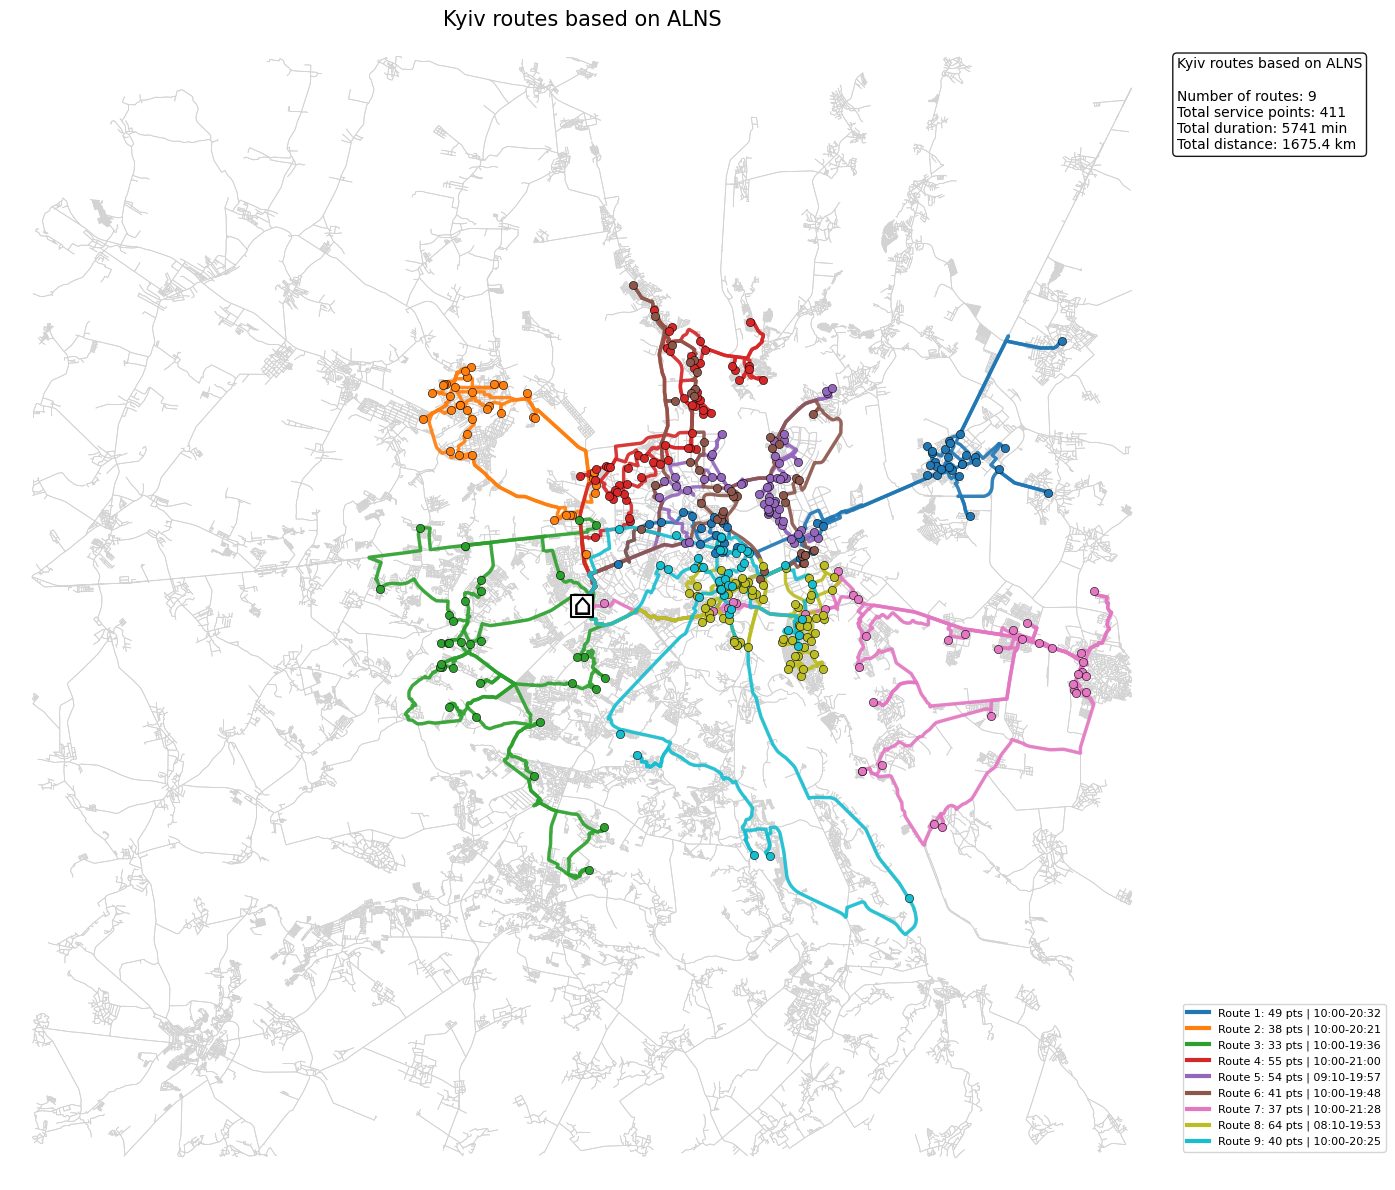

In [117]:
kyiv_fig, kyiv_ax = plot_solution_from_results(
    results_df=alns_all,
    case_name="Kyiv_small_1",
    depot=kyiv_depot,
    point_pool=kyiv_s_1_p,
    algorithm="ALNS",
    start_time_approach="Simulation",
    seed=42,
    network_dist_m=45000
)

/Users/anastasia/Library/Python/3.10/lib/python/site-packages/osmnx/graph.py:191: FutureWarning: The expected order of coordinates in `bbox` will change in the v2.0.0 release to `(left, bottom, right, top)`.
  G = graph_from_bbox(


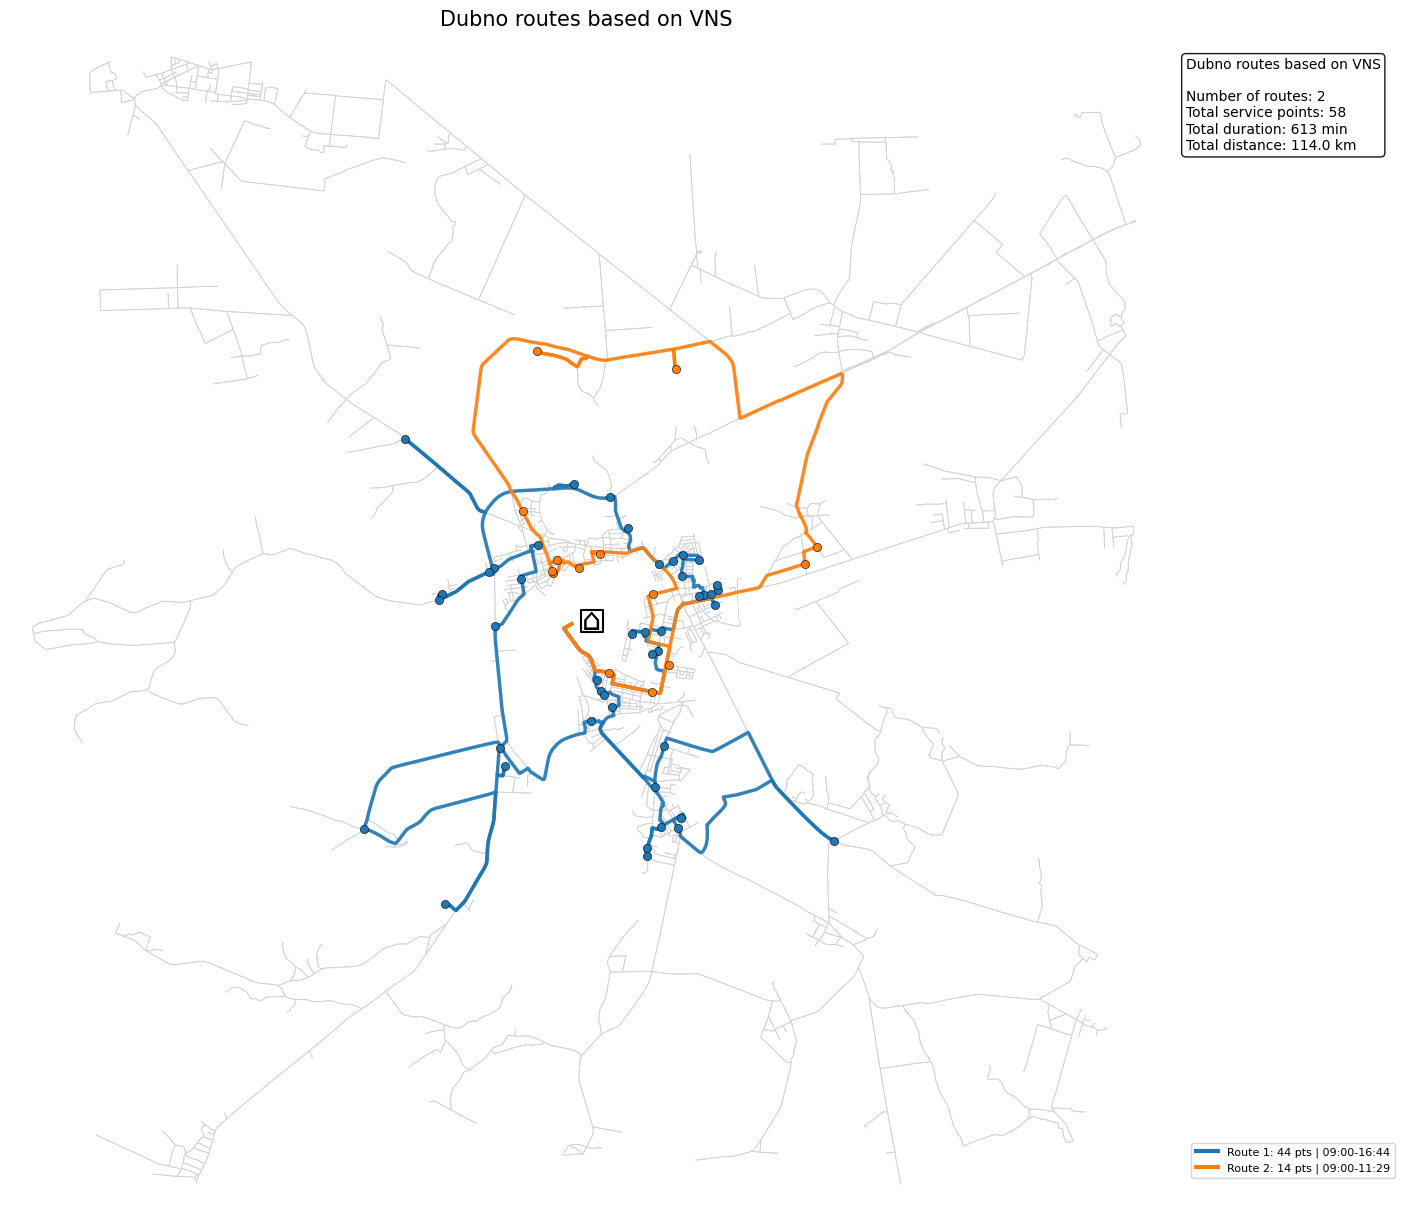

In [143]:
dubno_fig, dubno_ax = plot_solution_from_results(
    results_df=vns_all,
    case_name="dubno_gross_3",
    depot=dubno_depot,
    point_pool=dubno_g_3_p,
    algorithm="VNS",
    start_time_approach="Math",
    seed=42,
    network_dist_m=12000
)